# Modeling Human Activity States Using Hidden Markov Models
**Formative 2 — Group Assignment**

| | |
|---|---|
| **Edith Githinji** | iPhone 13  @ 100 Hz |
| **Liliane Gikundiro** |  iPhone 15 pro max @ 100 Hz |

**Activities:** Still · Standing · Walking · Jumping

**Sampling rate:** 100 Hz (harmonised between both devices)

### 1. Imports & Configuration

In [4]:
import os, warnings, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as sp_signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────
# Update this to point to your data directory
DATA_ROOT = pathlib.Path("./data")  # or the full path to your data folder
FIG_DIR = pathlib.Path("./figures")
FIG_DIR.mkdir(exist_ok=True)

# Verify data directory exists
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Could not find data directory at: {DATA_ROOT.absolute()}\n"
        f"Please update DATA_ROOT to point to your data folder."
    )
print(f"  ✓ Data root found : {DATA_ROOT.absolute()}")

# ── Constants ──────────────────────────────────────────────────────────────
ACTIVITIES      = ["still", "standing", "walking", "jumping"]
ACTIVITY_COLORS = {"still":"#3498db", "standing":"#2ecc71",
                   "walking":"#f39c12", "jumping":"#e74c3c"}
FS          = 100  # Sampling frequency in Hz
WINDOW_SIZE = 50   # Window size in samples (0.5 seconds at 100Hz)
STEP_SIZE   = 25   # Step size in samples (0.25 seconds at 100Hz)

print("=" * 60)
print("  HMM Human Activity Recognition")
print("=" * 60)
print(f"  Data directory : {DATA_ROOT}")
print(f"  Sampling rate  : {FS} Hz")
print(f"  Window size    : {WINDOW_SIZE} samples ({WINDOW_SIZE/FS:.2f} s)")
print(f"  Step size      : {STEP_SIZE} samples ({STEP_SIZE/FS:.2f} s)")
print(f"  Activities     : {ACTIVITIES}")
print(f"  Figures dir    : {FIG_DIR}")
print("=" * 60)

  ✓ Data root found : c:\Users\ADVANCED TECH\Downloads\markov_models\data
  HMM Human Activity Recognition
  Data directory : data
  Sampling rate  : 100 Hz
  Window size    : 50 samples (0.50 s)
  Step size      : 25 samples (0.25 s)
  Activities     : ['still', 'standing', 'walking', 'jumping']
  Figures dir    : figures


In [5]:
# ─── Cell 2: Load Data & Train/Test Split ──────────────────────────────────
import pathlib
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Start of added code to address NameError: 'DATA_ROOT' not defined ---
DATA_ROOT = pathlib.Path("./data") 

# Sanity check
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Could not find: {DATA_ROOT}\n"
        f"Check that DRIVE_PROJECT_PATH is correct and Drive is mounted."
    )
print(f"  ✓ Data root found : {DATA_ROOT}")
# --- End of added code ---

# ── Load a single recording folder → DataFrame ────────────────────────────
def load_recording(folder: pathlib.Path):
    acc_path  = folder / "Accelerometer.csv"
    gyro_path = folder / "Gyroscope.csv"

    if not acc_path.exists() or not gyro_path.exists():
        print(f"  [skip] {folder.name:<25} (missing Accelerometer.csv or Gyroscope.csv)")
        return None

    acc  = pd.read_csv(acc_path).rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyro = pd.read_csv(gyro_path).rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})

    acc  = acc.sort_values("time").reset_index(drop=True)
    gyro = gyro.sort_values("time").reset_index(drop=True)

    df = pd.merge_asof(
        acc,
        gyro[["time", "gyro_x", "gyro_y", "gyro_z"]],
        on="time",
        direction="nearest",
        tolerance=int(5e6)
    )
    df.dropna(subset=["gyro_x"], inplace=True)

    if df.empty:
        print(f"  [skip] {folder.name:<25} (merge produced 0 rows — check timestamps)")
        return None

    activity       = folder.name.split("_")[0]
    df["label"]    = activity
    df["filename"] = folder.name
    return df


# ── Discover all valid recording folders ──────────────────────────────────
all_subfolders = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

recording_registry = []
for folder in all_subfolders:
    activity = folder.name.split("_")[0]
    if activity not in ACTIVITIES:
        print(f"  [skip] {folder.name:<25} ('{activity}' not in {ACTIVITIES})")
        continue
    recording_registry.append((folder, activity))

print(f"  Found {len(recording_registry)} valid recording folders:")
for act in ACTIVITIES:
    n = sum(1 for _, a in recording_registry if a == act)
    print(f"    {act:<12}: {n} recording(s)")


# ── Load everything into one DataFrame ────────────────────────────────────
print("\n  Loading all recordings...")
all_dfs = []
for folder, activity in recording_registry:
    df = load_recording(folder)
    if df is not None:
        all_dfs.append(df)
        secs = (df["time"].max() - df["time"].min()) / 1e9
        print(f"  Loaded {folder.name:<25} → {len(df):5d} rows  ({secs:.1f}s)  (label: {activity})")

if not all_dfs:
    raise FileNotFoundError(
        "No recordings loaded. Check that your folders contain "
        "Accelerometer.csv and Gyroscope.csv (capital A and G)."
    )

all_df = pd.concat(all_dfs, ignore_index=True)


# ── Folder-level stratified train/test split ──────────────────────────────
TEST_SIZE    = 0.2
RANDOM_STATE = 42

folders_all    = [f for f, _ in recording_registry]
activities_all = [a for _, a in recording_registry]

folders_train, folders_test, _, _ = train_test_split(
    folders_all,
    activities_all,
    test_size=TEST_SIZE,
    stratify=activities_all,
    random_state=RANDOM_STATE
)

train_names = {f.name for f in folders_train}
test_names  = {f.name for f in folders_test}

train_df = all_df[all_df["filename"].isin(train_names)].reset_index(drop=True)
test_df  = all_df[all_df["filename"].isin(test_names)].reset_index(drop=True)


# ── Helper: seconds in a DataFrame ────────────────────────────────────────
def total_secs(df):
    """Sum the duration of each individual recording, not the overall span."""
    if df.empty:
        return 0
    
    total = 0
    for filename in df['filename'].unique():
        recording = df[df['filename'] == filename]
        duration = (recording["time"].max() - recording["time"].min()) / 1e9
        total += duration
    
    return total


# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'─'*75}")
print(f"  {'Split':<8} {'Rows':>10}  {'Recordings':>12}  {'Seconds':>10}  {'Minutes':>10}")
print(f"{'─'*75}")
for label, df in [("All", all_df), ("Train", train_df), ("Test", test_df)]:
    secs = total_secs(df)
    print(f"  {label:<8} {len(df):>10,}  {df['filename'].nunique():>12}  {secs:>10.1f}  {secs/60:>10.2f}")
print(f"{'─'*75}")

print(f"\n  Train class distribution:")
print(f"  {'Activity':<12} {'Rows':>8}  {'Seconds':>9}  {'Minutes':>9}  {'Recordings':>12}")
print(f"  {'─'*56}")
for act in ACTIVITIES:
    sub  = train_df[train_df["label"] == act]
    secs = total_secs(sub)
    print(f"  {act:<12} {len(sub):>8,}  {secs:>9.1f}  {secs/60:>9.2f}  {sub['filename'].nunique():>12}")

print(f"\n  Test class distribution:")
print(f"  {'Activity':<12} {'Rows':>8}  {'Seconds':>9}  {'Minutes':>9}  {'Recordings':>12}")
print(f"  {'─'*56}")
for act in ACTIVITIES:
    sub  = test_df[test_df["label"] == act]
    secs = total_secs(sub)
    print(f"  {act:<12} {len(sub):>8,}  {secs:>9.1f}  {secs/60:>9.2f}  {sub['filename'].nunique():>12}")

  ✓ Data root found : data
  Found 50 valid recording folders:
    still       : 12 recording(s)
    standing    : 13 recording(s)
    walking     : 13 recording(s)
    jumping     : 12 recording(s)

  Loading all recordings...
  Loaded jumping_1                 →   784 rows  (7.9s)  (label: jumping)
  Loaded jumping_10                →   705 rows  (7.1s)  (label: jumping)
  Loaded jumping_11                →   745 rows  (7.5s)  (label: jumping)
  Loaded jumping_12                →   577 rows  (5.8s)  (label: jumping)
  Loaded jumping_2                 →   741 rows  (7.4s)  (label: jumping)
  Loaded jumping_3                 →   720 rows  (7.2s)  (label: jumping)
  Loaded jumping_4                 →   815 rows  (8.2s)  (label: jumping)
  Loaded jumping_5                 →   786 rows  (7.9s)  (label: jumping)
  Loaded jumping_6                 →   749 rows  (7.5s)  (label: jumping)
  Loaded jumping_7                 →   532 rows  (5.3s)  (label: jumping)
  Loaded jumping_8              

## 1. Raw Data Visualisation


[Plot] Raw sensor signals per activity...


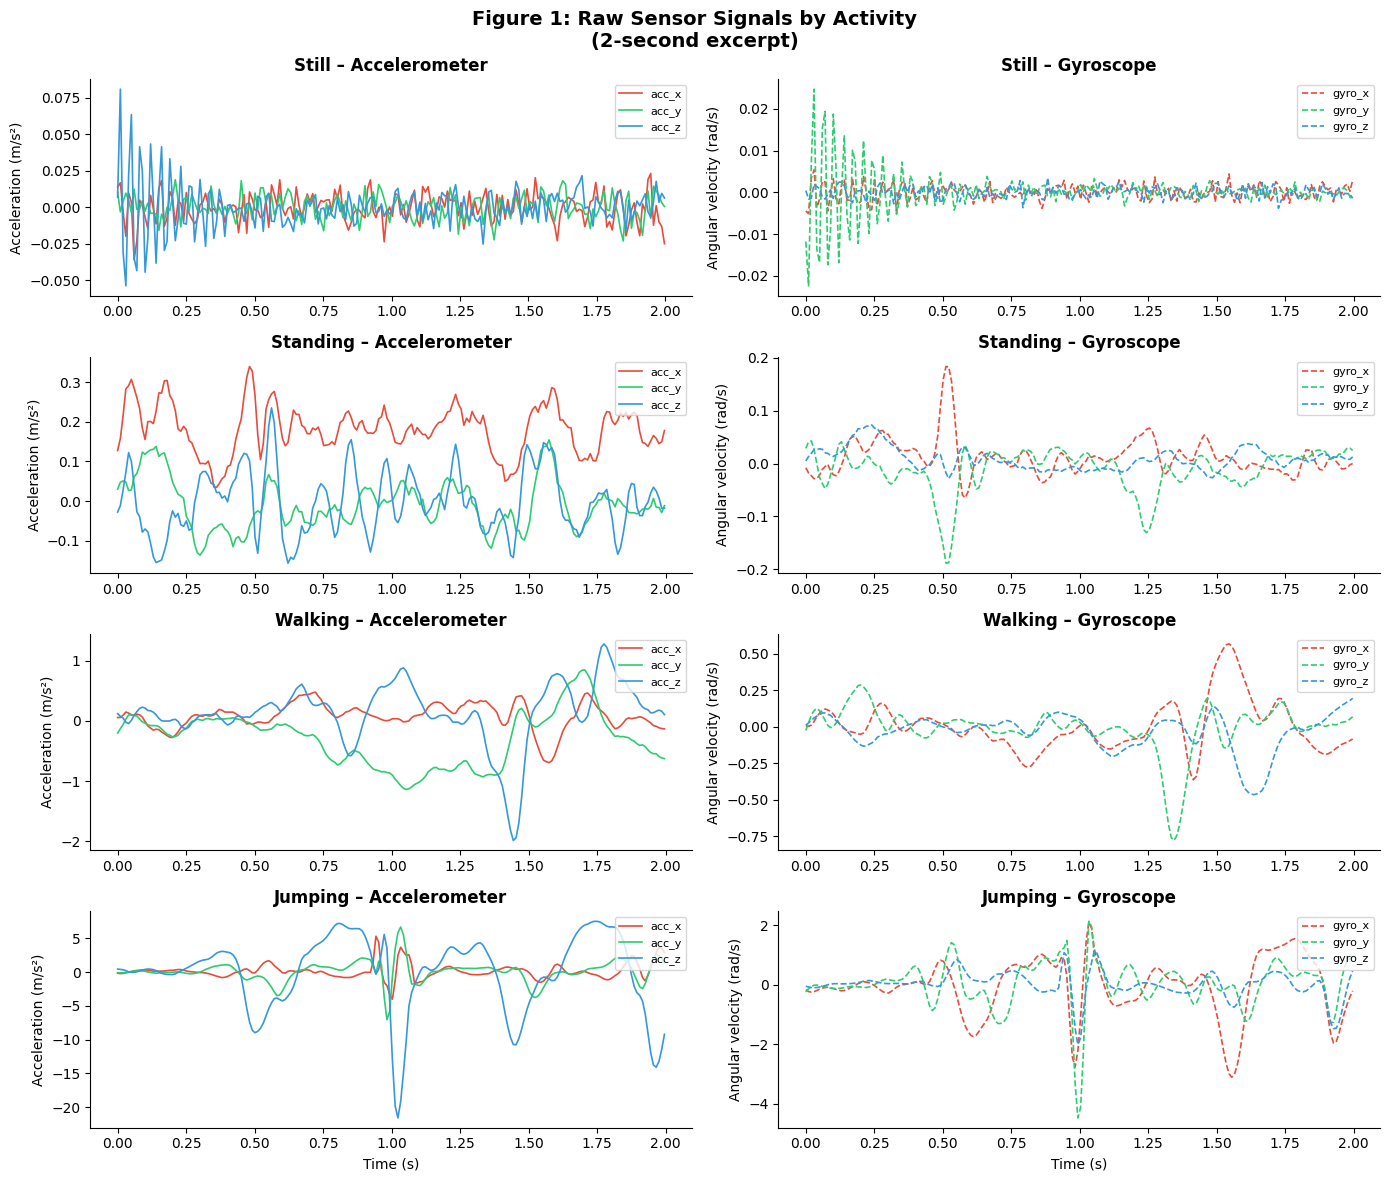

  → Saved fig1_raw_signals.png


In [6]:
# ─── Cell 3: Visualise Raw Sensor Data ─────────────────────────────────────
print("\n[Plot] Raw sensor signals per activity...")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle("Figure 1: Raw Sensor Signals by Activity\n(2-second excerpt)",
             fontsize=14, fontweight='bold')

for row, activity in enumerate(ACTIVITIES):
    sub = all_df[all_df['label'] == activity].iloc[:200].copy()

    # Build time axis from nanosecond timestamps
    t = (sub['time'].values - sub['time'].values[0]) / 1e9   # ns → seconds

    # Accelerometer
    ax = axes[row, 0]
    ax.plot(t, sub['acc_x'], label='acc_x', color='#e74c3c', lw=1.2)
    ax.plot(t, sub['acc_y'], label='acc_y', color='#2ecc71', lw=1.2)
    ax.plot(t, sub['acc_z'], label='acc_z', color='#3498db', lw=1.2)
    ax.set_title(f'{activity.capitalize()} – Accelerometer', fontweight='bold')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if row == 3: ax.set_xlabel('Time (s)')

    # Gyroscope
    ax2 = axes[row, 1]
    ax2.plot(t, sub['gyro_x'], label='gyro_x', color='#e74c3c', lw=1.2, linestyle='--')
    ax2.plot(t, sub['gyro_y'], label='gyro_y', color='#2ecc71', lw=1.2, linestyle='--')
    ax2.plot(t, sub['gyro_z'], label='gyro_z', color='#3498db', lw=1.2, linestyle='--')
    ax2.set_title(f'{activity.capitalize()} – Gyroscope', fontweight='bold')
    ax2.set_ylabel('Angular velocity (rad/s)')
    ax2.legend(fontsize=8, loc='upper right')
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    if row == 3: ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_raw_signals.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → Saved fig1_raw_signals.png")

## 4. Feature Extraction

**7 features per 0.5s window (50 samples @ 100 Hz):**

| # | Feature | Domain | Justification |
|---|---------|--------|---------------|
| 1 | acc_rms | Time | Overall motion intensity; jumps >> walks >> standing > still |
| 2 | acc_var | Time | Variance of magnitude; distinguishes steady vs. dynamic states |
| 3 | sma | Time | Signal Magnitude Area; proportional to energy |
| 4 | gyro_rms | Time | Rotation magnitude; complements accelerometer |
| 5 | corr_xy | Time | X-Y acceleration correlation; walking has anti-correlated sway |
| 6 | dom_freq | Frequency | Peak FFT frequency; still≈0 Hz, walk≈1.8 Hz, jump≈2.5 Hz |
| 7 | spec_energy | Frequency | Energy in 0.5–4 Hz band; isolates locomotion, rejects gravity DC |

**Normalisation:** Z-score (StandardScaler fit on train, applied to test). Justified because Gaussian HMM emissions assume zero-mean unit-variance observations.

In [7]:


def extract_features(window_df):
    ax = window_df['acc_x'].values
    ay = window_df['acc_y'].values
    az = window_df['acc_z'].values
    gx = window_df['gyro_x'].values
    gy = window_df['gyro_y'].values
    gz = window_df['gyro_z'].values

    # Magnitudes
    acc_mag  = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    # 1. Accelerometer RMS
    acc_rms = np.sqrt(np.mean(acc_mag**2))

    # 2. Accelerometer variance
    acc_var = np.var(acc_mag)

    # 3. Signal Magnitude Area
    sma = np.mean(np.abs(ax) + np.abs(ay) + np.abs(az)) / 3.0

    # 4. Gyroscope RMS
    gyro_rms = np.sqrt(np.mean(gyro_mag**2))

    # 5. Correlation acc_x vs acc_y
    if np.std(ax) < 1e-8 or np.std(ay) < 1e-8:
        corr_xy = 0.0
    else:
        corr_xy = float(np.corrcoef(ax, ay)[0, 1])

    # 6. Dominant frequency (FFT of acc_magnitude, ignoring DC)
    N = len(acc_mag)
    freqs = fftfreq(N, d=1.0/FS)
    fft_vals = np.abs(fft(acc_mag - acc_mag.mean()))  # remove DC
    pos_mask = (freqs > 0.1) & (freqs < FS/2)
    if pos_mask.sum() > 0:
        dom_freq = freqs[pos_mask][np.argmax(fft_vals[pos_mask])]
    else:
        dom_freq = 0.0

    # 7. Spectral energy in 0.5–4 Hz
    band_mask = (freqs >= 0.5) & (freqs <= 4.0)
    spec_energy = float(np.sum(fft_vals[band_mask]**2)) / N

    return [acc_rms, acc_var, sma, gyro_rms, corr_xy, dom_freq, spec_energy]

FEATURE_NAMES = ['acc_rms', 'acc_var', 'sma', 'gyro_rms', 'corr_xy', 'dom_freq', 'spec_energy']

def windowed_features(df, window=WINDOW_SIZE, step=STEP_SIZE):
    features, labels = [], []
    for start in range(0, len(df) - window + 1, step):
        w = df.iloc[start:start+window]
        lab = w['label'].mode()[0]
        feat = extract_features(w)
        features.append(feat)
        labels.append(lab)
    return np.array(features), np.array(labels)

print("\n[Feature] Extracting windowed features...")
X_train_raw, y_train = windowed_features(train_df)
X_test_raw,  y_test  = windowed_features(test_df)
print(f"  Train feature matrix : {X_train_raw.shape}")
print(f"  Test  feature matrix : {X_test_raw.shape}")
print(f"  Features: {FEATURE_NAMES}")

# Z-score normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print("  Z-score normalisation applied (fit on train, transform test)")



[Feature] Extracting windowed features...
  Train feature matrix : (1230, 7)
  Test  feature matrix : (301, 7)
  Features: ['acc_rms', 'acc_var', 'sma', 'gyro_rms', 'corr_xy', 'dom_freq', 'spec_energy']
  Z-score normalisation applied (fit on train, transform test)


## 5. Feature Distribution Visualisation

In [8]:
print("\n[Plot] Feature distributions per activity...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Figure 2: Feature Distributions by Activity (Z-scored)\n"
             "Features 1–7: acc_rms, acc_var, sma, gyro_rms, corr_xy, dom_freq, spec_energy",
             fontsize=12, fontweight='bold')

feat_display = FEATURE_NAMES + ['']
for i in range(7):
    ax = axes[i//4, i%4]
    for act in ACTIVITIES:
        mask = y_train == act
        ax.hist(X_train[mask, i], bins=20, alpha=0.6,
                label=act, color=ACTIVITY_COLORS[act], density=True)
    ax.set_title(FEATURE_NAMES[i], fontweight='bold', fontsize=10)
    ax.set_xlabel('Z-score'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[1, 3].axis('off')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.close()
print("  → Saved fig2_feature_distributions.png")



[Plot] Feature distributions per activity...
  → Saved fig2_feature_distributions.png
